# HumanLens AI — Voice Feature Analysis

## Objective

This notebook develops the acoustic feature-extraction component of
the HumanLens Voice Layer.

The objective is to extract non-identifying speech characteristics
that can later contribute to the Multimodal Fusion Engine.

## Voice Features

The initial feature set includes:

- Fundamental frequency (pitch)
- Speech rate proxy
- Pause frequency
- RMS energy / intensity
- Audio quality indicators

## Privacy Principle

The Voice Layer is designed to analyze acoustic characteristics rather
than identify the speaker.

The system should not perform:

- Speaker identification
- Voice biometric identification
- Identity tracking
- Demographic inference

## Research Principle

Voice features are treated as contextual communication signals.

They must not be interpreted as definitive evidence of a person's
emotion, personality, mental state, or intent.

## Limitation

Acoustic features can be strongly affected by:

- Microphone quality
- Background noise
- Distance from microphone
- Recording environment
- Individual speaking style
- Language
- Accent
- Speaking ability

Therefore, audio quality must be considered when interpreting the
features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Basic libraries imported successfully.")

Basic libraries imported successfully.


In [2]:
%pip install librosa soundfile

Note: you may need to restart the kernel to use updated packages.


In [3]:
import librosa
import soundfile as sf

print("Librosa version:", librosa.__version__)
print("Audio libraries loaded successfully.")

Librosa version: 1.0.0
Audio libraries loaded successfully.


In [4]:
audio_dir = Path("../data/audio")
audio_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Audio directory:", audio_dir)

Audio directory: ..\data\audio


In [5]:
sample_rate = 16000
duration = 5

t = np.linspace(
    0,
    duration,
    int(sample_rate * duration),
    endpoint=False
)

# Fundamental frequency of 180 Hz
frequency = 180

audio_signal = (
    0.3 *
    np.sin(
        2 * np.pi * frequency * t
    )
)

print("Synthetic audio signal created.")
print("Sample rate:", sample_rate)
print("Duration:", duration, "seconds")

Synthetic audio signal created.
Sample rate: 16000
Duration: 5 seconds


In [6]:
audio_with_pauses = audio_signal.copy()

pause_ranges = [
    (1.0, 1.4),
    (2.2, 2.8),
    (3.7, 4.0)
]

for start, end in pause_ranges:

    start_index = int(start * sample_rate)
    end_index = int(end * sample_rate)

    audio_with_pauses[
        start_index:end_index
    ] = 0

print("Simulated pauses added.")

Simulated pauses added.


In [7]:
test_audio_path = (
    audio_dir / "voice_test_signal.wav"
)

sf.write(
    test_audio_path,
    audio_with_pauses,
    sample_rate
)

print("Test audio saved:")
print(test_audio_path)

Test audio saved:
..\data\audio\voice_test_signal.wav


In [8]:
audio, sr = librosa.load(
    test_audio_path,
    sr=None,
    mono=True
)

print("Audio loaded successfully.")
print("Sample rate:", sr)
print("Number of samples:", len(audio))
print(
    "Duration:",
    len(audio) / sr,
    "seconds"
)

Audio loaded successfully.
Sample rate: 16000
Number of samples: 80000
Duration: 5.0 seconds


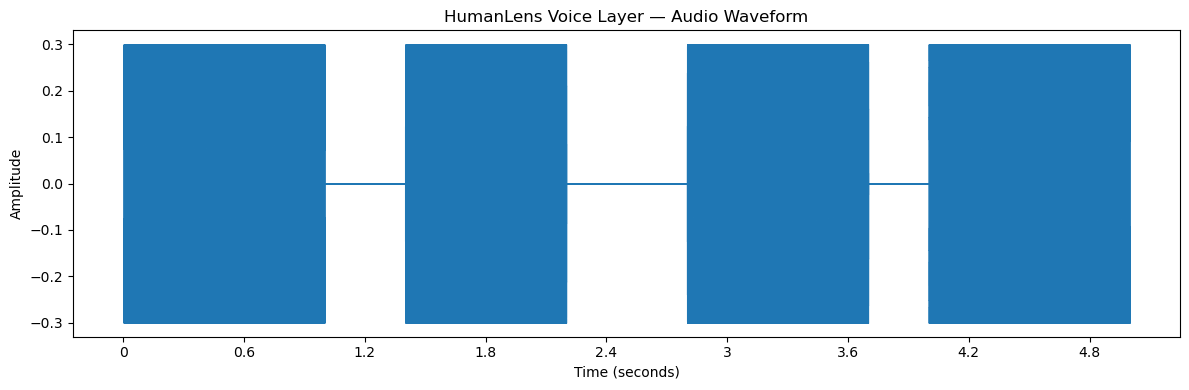

In [9]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("HumanLens Voice Layer — Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [10]:
import librosa.display

In [11]:
rms = librosa.feature.rms(
    y=audio
)[0]

rms_mean = float(
    np.mean(rms)
)

rms_std = float(
    np.std(rms)
)

print("RMS Energy Features")
print("=" * 40)
print("Mean RMS:", rms_mean)
print("RMS standard deviation:", rms_std)

RMS Energy Features
Mean RMS: 0.1616044044494629
RMS standard deviation: 0.08273792266845703


In [12]:
pitch, voiced_flag, voiced_prob = (
    librosa.pyin(
        audio,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=sr
    )
)

In [13]:
valid_pitch = pitch[
    ~np.isnan(pitch)
]

mean_pitch = (
    float(np.mean(valid_pitch))
    if len(valid_pitch) > 0
    else 0.0
)

pitch_std = (
    float(np.std(valid_pitch))
    if len(valid_pitch) > 0
    else 0.0
)

print("Pitch Features")
print("=" * 40)
print("Mean pitch:", round(mean_pitch, 2), "Hz")
print("Pitch variation:", round(pitch_std, 2), "Hz")

Pitch Features
Mean pitch: 180.28 Hz
Pitch variation: 0.76 Hz


In [14]:
voiced_frames = np.sum(
    voiced_flag == True
)

total_frames = len(
    voiced_flag
)

voiced_ratio = (
    voiced_frames / total_frames
    if total_frames > 0
    else 0
)

print(
    "Voiced-frame ratio:",
    round(voiced_ratio, 4)
)

Voiced-frame ratio: 0.8153


In [15]:
energy_threshold = (
    rms_mean * 0.30
)

silent_frames = (
    rms < energy_threshold
)

pause_ratio = (
    np.mean(silent_frames)
)

print("Pause ratio:", round(pause_ratio, 4))

Pause ratio: 0.1847


In [16]:
pause_transitions = np.diff(
    silent_frames.astype(int)
)

pause_starts = np.sum(
    pause_transitions == 1
)

print(
    "Approximate pause count:",
    int(pause_starts)
)

Approximate pause count: 3


In [17]:
active_frames = np.sum(
    ~silent_frames
)

active_duration = (
    active_frames * 512 / sr
)

print(
    "Estimated active speech duration:",
    round(active_duration, 2),
    "seconds"
)

Estimated active speech duration: 4.1 seconds


In [18]:
speech_activity_ratio = (
    active_duration /
    (len(audio) / sr)
)

print(
    "Speech activity ratio:",
    round(speech_activity_ratio, 4)
)

Speech activity ratio: 0.8192


In [19]:
voice_features = {
    "sample_rate": sr,
    "duration_seconds": len(audio) / sr,
    "mean_rms_energy": rms_mean,
    "rms_energy_std": rms_std,
    "mean_pitch_hz": mean_pitch,
    "pitch_std_hz": pitch_std,
    "voiced_ratio": voiced_ratio,
    "pause_ratio": pause_ratio,
    "pause_count": int(pause_starts),
    "speech_activity_ratio": speech_activity_ratio
}

voice_features_df = pd.DataFrame(
    [voice_features]
)

display(voice_features_df)

,sample_rate,duration_seconds,mean_rms_energy,rms_energy_std,mean_pitch_hz,pitch_std_hz,voiced_ratio,pause_ratio,pause_count,speech_activity_ratio
0,16000,5.0,0.161604,0.082738,180.276538,0.762561,0.815287,0.184713,3,0.8192


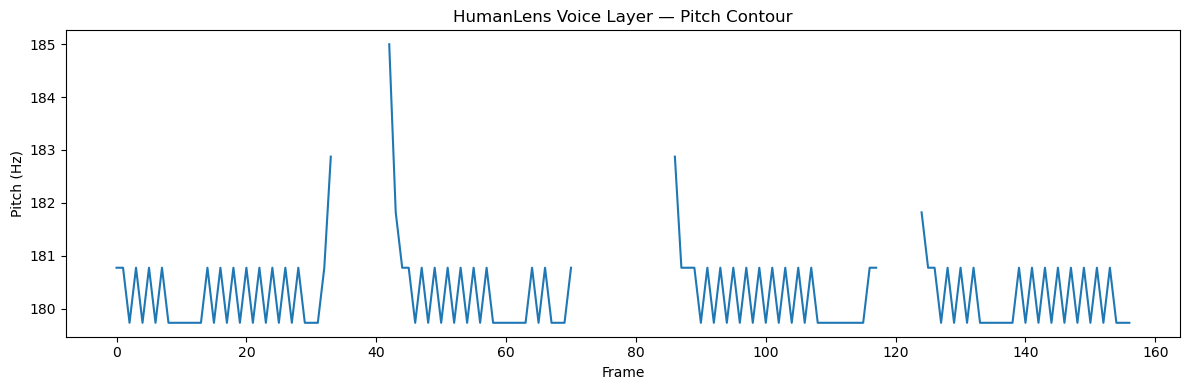

In [20]:
plt.figure(figsize=(12, 4))

plt.plot(
    pitch
)

plt.title("HumanLens Voice Layer — Pitch Contour")
plt.xlabel("Frame")
plt.ylabel("Pitch (Hz)")

plt.tight_layout()
plt.show()

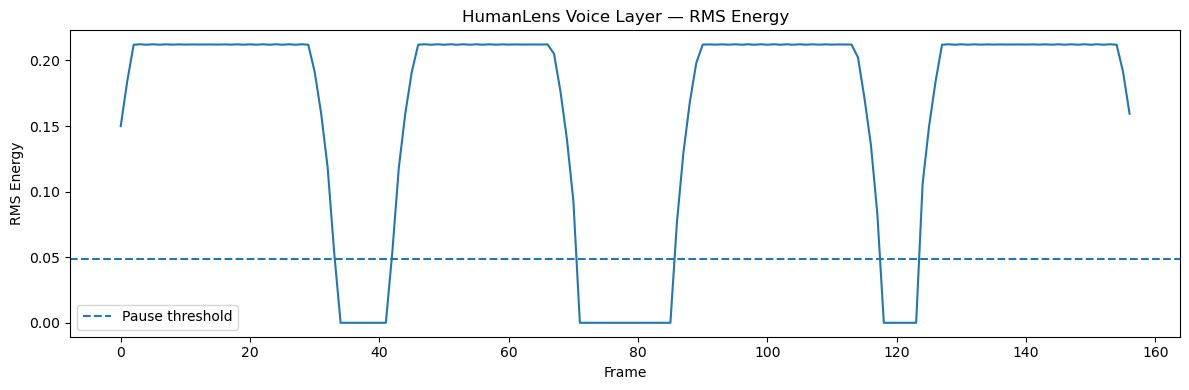

In [21]:
plt.figure(figsize=(12, 4))

plt.plot(
    rms
)

plt.axhline(
    energy_threshold,
    linestyle="--",
    label="Pause threshold"
)

plt.title("HumanLens Voice Layer — RMS Energy")
plt.xlabel("Frame")
plt.ylabel("RMS Energy")

plt.legend()

plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import MinMaxScaler

normalization_features = [
    "mean_rms_energy",
    "rms_energy_std",
    "mean_pitch_hz",
    "pitch_std_hz",
    "voiced_ratio",
    "pause_ratio",
    "speech_activity_ratio"
]

feature_scaler = MinMaxScaler()

normalized_values = feature_scaler.fit_transform(
    voice_features_df[
        normalization_features
    ]
)

normalized_voice_df = pd.DataFrame(
    normalized_values,
    columns=normalization_features
)

display(normalized_voice_df)

,mean_rms_energy,rms_energy_std,mean_pitch_hz,pitch_std_hz,voiced_ratio,pause_ratio,speech_activity_ratio
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
voice_intensity_score = (
    0.50 *
    normalized_voice_df[
        "mean_rms_energy"
    ]

    +

    0.30 *
    normalized_voice_df[
        "rms_energy_std"
    ]

    +

    0.20 *
    normalized_voice_df[
        "pitch_std_hz"
    ]
)

voice_features_df[
    "voice_intensity_proxy"
] = voice_intensity_score.values

print(
    "Voice intensity proxy:",
    round(
        float(
            voice_features_df[
                "voice_intensity_proxy"
            ].iloc[0]
        ),
        4
    )
)

Voice intensity proxy: 0.0


In [24]:
results_dir = Path("../results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

voice_results_path = (
    results_dir /
    "voice_feature_baseline.csv"
)

voice_features_df.to_csv(
    voice_results_path,
    index=False
)

print("Voice features saved successfully.")
print(voice_results_path)

Voice features saved successfully.
..\results\voice_feature_baseline.csv


In [25]:
print(
    "Test audio exists:",
    test_audio_path.exists()
)

print(test_audio_path)

Test audio exists: True
..\data\audio\voice_test_signal.wav


# Voice Feature Analysis — Research Findings

## Objective

The HumanLens Voice Layer was designed to extract non-identifying
acoustic and temporal features from speech.

## Extracted Features

The baseline extracts:

- Mean pitch
- Pitch variation
- RMS energy
- RMS energy variation
- Voiced-frame ratio
- Pause ratio
- Approximate pause count
- Speech activity ratio

## Privacy

The baseline does not perform speaker identification or voice
biometric identification.

The extracted features describe acoustic characteristics rather than
speaker identity.

## Interpretation

Voice features are treated as communication-level signals.

For example, increased acoustic energy may indicate a more intense
speaking pattern, but it does not prove anger, aggression, stress,
or any other psychological state.

## Limitations

Voice features can be affected by:

- Microphone quality
- Environmental noise
- Recording distance
- Individual speaking style
- Accent
- Language
- Background sounds

The current speech-rate feature is a speech-activity proxy rather than
a true words-per-minute measurement.

The current experiment uses controlled test audio and therefore does
not establish population-level thresholds.

## HumanLens Integration

The voice feature vector will later be combined with:

- Text toxicity
- Text aggression
- Text emotion
- Facial-expression signals
- Behavioral context

through the Multimodal Fusion Engine.

## Next Stage

The next stage is privacy-preserving facial-expression feature
extraction without facial recognition or identity tracking.

In [26]:
%pip install transformers torch accelerate sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install faster-whisper

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   -------------------------------

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\shash\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\shash\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\shash\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\shash\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "C:\Users\shash\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
  File "C:\Users\shash\anaconda3\Lib\socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
  F

In [2]:
%pip install faster-whisper --no-cache-dir --timeout 300 --retries 10

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.1 MB 548.5 kB/s eta 0:00:02
   ------------------ --------------------- 0.5/1.1 MB 548.5 kB/s eta 0:00:02
   ------------------ --------------------- 0.5/1.1 MB 548.5 kB/s eta 0:00:02
   ---------------------------- ----------- 0.8/1.1 MB 498.2 kB/s eta 0:00:01
   ---------------------------- ----------- 0.8/1.1 MB 498.2 kB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 603.5 kB/s  0:00:01
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/19

In [1]:
import faster_whisper
print("faster-whisper:", faster_whisper.__version__)

faster-whisper: 1.2.1


In [8]:
from faster_whisper import WhisperModel
from pathlib import Path

# ---------------------------------------------------------
# AUDIO FILE
# ---------------------------------------------------------

audio_path = Path("../data/audio/my_hindi_test.wav")

print("Looking for audio at:")
print(audio_path.resolve())
print()

if not audio_path.exists():
    raise FileNotFoundError(
        f"Audio file not found:\n{audio_path.resolve()}"
    )

print("✅ Audio file found!")
print(f"File size: {audio_path.stat().st_size / 1024:.2f} KB")
print()

# ---------------------------------------------------------
# LOAD WHISPER
# ---------------------------------------------------------

print("Loading faster-whisper tiny model...")

model = WhisperModel(
    "tiny",
    device="cpu",
    compute_type="int8"
)

print("✅ faster-whisper model loaded")
print()

# ---------------------------------------------------------
# TRANSCRIBE HINDI
# ---------------------------------------------------------

print("Transcribing:")
print(audio_path.name)
print("-" * 60)

segments, info = model.transcribe(
    str(audio_path),
    language="hi",
    beam_size=5,
    vad_filter=True
)

transcript_parts = []

for segment in segments:
    text = segment.text.strip()

    if text:
        print(
            f"[{segment.start:.2f}s → {segment.end:.2f}s] {text}"
        )
        transcript_parts.append(text)

transcript = " ".join(transcript_parts)

# ---------------------------------------------------------
# FINAL RESULT
# ---------------------------------------------------------

print()
print("=" * 60)
print("HUMANLENS VOICE TEST RESULT")
print("=" * 60)

print("Audio file:", audio_path.name)
print("Detected language:", info.language)
print(
    "Language probability:",
    round(info.language_probability, 4)
)

print()
print("TRANSCRIPT:")
print("-" * 60)
print(transcript)
print("-" * 60)

Looking for audio at:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_hindi_test.wav



FileNotFoundError: Audio file not found:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_hindi_test.wav

In [5]:
from pathlib import Path

audio_dir = Path(r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio")

print("Audio folder:")
print(audio_dir)
print()

print("Folder exists:", audio_dir.exists())
print()

if audio_dir.exists():
    print("Files inside audio folder:")
    print("=" * 70)

    for file in audio_dir.iterdir():
        print(file.name)
else:
    print("❌ AUDIO FOLDER NOT FOUND")

Audio folder:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio

Folder exists: True

Files inside audio folder:
my_english_test.wav
my_hindi_test.wav
voice_test_signal.wav


In [6]:
from pathlib import Path

audio_path = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_hindi_test.wav"
)

print("Audio file:")
print(audio_path)

print()
print("Exists:", audio_path.exists())

if not audio_path.exists():
    raise FileNotFoundError(f"File not found: {audio_path}")

print("✅ AUDIO FILE FOUND!")
print(f"Size: {audio_path.stat().st_size / 1024:.2f} KB")

Audio file:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_hindi_test.wav

Exists: True
✅ AUDIO FILE FOUND!
Size: 5139.20 KB


In [7]:
from faster_whisper import WhisperModel

print("Loading faster-whisper tiny...")
print()

model = WhisperModel(
    "tiny",
    device="cpu",
    compute_type="int8"
)

print("✅ Model loaded successfully")
print()
print("Transcribing:", audio_path.name)
print("=" * 70)

segments, info = model.transcribe(
    str(audio_path),
    language="hi",
    beam_size=5,
    vad_filter=True
)

transcript_parts = []

for segment in segments:
    text = segment.text.strip()

    if text:
        print(
            f"[{segment.start:.2f}s - {segment.end:.2f}s] {text}"
        )
        transcript_parts.append(text)

transcript = " ".join(transcript_parts)

print()
print("=" * 70)
print("FINAL TRANSCRIPTION")
print("=" * 70)
print(transcript)
print("=" * 70)

print()
print("Detected language:", info.language)
print("Language probability:", round(info.language_probability, 4))

Loading faster-whisper tiny...

✅ Model loaded successfully

Transcribing: my_hindi_test.wav
[1.65s - 3.07s] 저희가 इक empowerṭ
[4.17s - 8.66s] इलूवष्युऒव तो piston custom
[8.76s - 11.92s] ईह जोूवषलोक आदचện ब होग करा जच्योग
[15.88s - 17.76s] ारंछ अ हदच कर norm
[17.76s - 21.04s] अश्ऌ potato

FINAL TRANSCRIPTION
저희가 इक empowerṭ इलूवष्युऒव तो piston custom ईह जोूवषलोक आदचện ब होग करा जच्योग ारंछ अ हदच कर norm अश्ऌ potato

Detected language: hi
Language probability: 1


In [2]:
from faster_whisper import WhisperModel

print("✅ WhisperModel imported successfully")

✅ WhisperModel imported successfully


In [1]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

print("✅ Hugging Face symlink mode disabled")

✅ Hugging Face symlink mode disabled


In [2]:
from faster_whisper import WhisperModel

print("✅ Faster-Whisper imported")

✅ Faster-Whisper imported


In [3]:
model_base = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

print("✅ Whisper BASE loaded successfully")

✅ Whisper BASE loaded successfully


In [2]:
import os

# Reduce CPU/MKL memory usage
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

print("✅ Low-memory environment configured")

✅ Low-memory environment configured


In [3]:
from faster_whisper import WhisperModel

print("Loading Whisper Tiny...")

model = WhisperModel(
    "tiny",
    device="cpu",
    compute_type="int8",
    cpu_threads=1,
    num_workers=1
)

print("✅ Whisper Tiny loaded successfully!")

Loading Whisper Tiny...
✅ Whisper Tiny loaded successfully!


In [4]:
from pathlib import Path

audio_path = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_clear_english_test.wav"
)

segments, info = model.transcribe(
    str(audio_path),
    language="en",
    beam_size=5,
    temperature=0,
    vad_filter=False,
    condition_on_previous_text=False
)

transcript = " ".join(
    segment.text.strip()
    for segment in segments
    if segment.text.strip()
)

print("=" * 70)
print("CLEAR ENGLISH ASR TEST")
print("=" * 70)
print("Detected language:", info.language)
print("Probability:", round(info.language_probability, 4))
print()
print("Transcript:")
print(transcript)

CLEAR ENGLISH ASR TEST
Detected language: en
Probability: 1

Transcript:
just recording for human lens artificial air intelligence and I want to say that fuck you bitch mother fucking bitch bloody bastard I'm so angry about it


In [3]:
from pathlib import Path
import sys

# Find the HumanLens AI research_ml project root
current = Path.cwd()

project_root = None

for path in [current] + list(current.parents):
    if (path / "src").is_dir() and (path / "models").is_dir():
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        "Could not find the HumanLens AI research_ml project root."
    )

# Add project root to Python's import path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:")
print(project_root)

print("\nChecking src package...")
print((project_root / "src").exists())

print("\nPython import path fixed.")

Project root:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml

Checking src package...
True

Python import path fixed.


In [6]:
from pathlib import Path

p = Path(r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\src\text\toxicity.py")

print("FILE EXISTS:", p.exists())
print("\n" + "="*70)
print(p.read_text(encoding="utf-8"))
print("="*70)

FILE EXISTS: True

"""
HumanLens AI — Multilingual Toxicity Detection Module
Member 3: Research / ML Lead

Implements:
1. Primary Model: textdetox/bert-multilingual-toxicity-classifier
2. Research Comparison Model: textdetox/xlmr-large-toxicity-classifier-v2
3. Fast Baseline: TF-IDF + Calibrated Logistic Regression (models/text/toxicity_model.pkl)
4. Robust dynamic label mapping via model.config.id2label
"""

from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import joblib

from src.text.preprocessing import clean_text, extract_text_features, detect_language


class ToxicityScorer:
    """
    Unified toxicity detection engine supporting both pretrained transformer pipelines
    and fast, low-latency calibrated baseline models.
    """

    PRIMARY_MODEL_NAME = "textdetox/bert-multilingual-toxicity-classifier"
    COMPARISON_MODEL_NAME = "textdetox/xlmr-large-toxicity-classifier-v2"

    def __init__(
        self,
        use_transformer: bool = True,
 

In [8]:
from src.text.toxicity import ToxicityScorer

# Use the lightweight local TF-IDF + Logistic Regression model
scorer = ToxicityScorer(use_transformer=False)

# Analyze the ASR transcript
result = scorer.score(
    transcript,
    model_type="fast"
)

print("=" * 70)
print("HUMANLENS AI — VOICE → ASR → TOXICITY")
print("=" * 70)

print("\nTranscript:")
print(transcript)

print("\nAnalysis Result:")
print(result)

AttributeError: 'LogisticRegression' object has no attribute 'multi_class'

In [9]:
# ============================================================
# FIX: OLD LOGISTIC REGRESSION MODEL COMPATIBILITY
# ============================================================

import sklearn

print("Current scikit-learn version:", sklearn.__version__)

# The saved model was created with an older sklearn version.
# Add the missing compatibility attribute.
if hasattr(scorer, "fast_model") and scorer.fast_model is not None:
    if not hasattr(scorer.fast_model, "multi_class"):
        scorer.fast_model.multi_class = "auto"
        print("Added missing LogisticRegression.multi_class = 'auto'")

# Test the actual HumanLens text analysis
result = scorer.score(
    transcript,
    model_type="fast"
)

print("\n" + "=" * 70)
print("HUMANLENS AI — VOICE → ASR → TEXT ANALYSIS")
print("=" * 70)

print("\nTranscript:")
print(transcript)

print("\nResult:")
print(result)

Current scikit-learn version: 1.7.2
Added missing LogisticRegression.multi_class = 'auto'

HUMANLENS AI — VOICE → ASR → TEXT ANALYSIS

Transcript:
just recording for human lens artificial air intelligence and I want to say that fuck you bitch mother fucking bitch bloody bastard I'm so angry about it

Result:
{'toxicity': 0.9876, 'toxicity_score': 0.9876, 'is_toxic': True, 'confidence': 0.9752, 'model_used': 'FAST BASELINE (TF-IDF + Logistic Regression)', 'backend': 'MODEL BACKEND (TF-IDF + Logistic Regression)', 'language': 'English', 'status': 'available', 'text_features': {'char_count': 153, 'word_count': 27, 'caps_ratio': 0.0159, 'exclamation_count': 0, 'question_count': 0, 'excessive_punctuation': False, 'is_all_caps': False, 'language_meta': {'language': 'English', 'language_code': 'en', 'script': 'Latin', 'is_code_mixed': False, 'confidence': 0.95}}}


In [10]:
# ============================================================
# HUMANLENS AI — REAL VOICE FEATURE EXTRACTION
# ============================================================

import librosa
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# REAL AUDIO FILE
# ------------------------------------------------------------

real_audio_path = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_clear_english_test.wav"
)

print("=" * 70)
print("HUMANLENS AI — REAL VOICE FEATURE ANALYSIS")
print("=" * 70)

print("\nAudio file:")
print(real_audio_path)

if not real_audio_path.exists():
    raise FileNotFoundError(
        f"Audio file not found:\n{real_audio_path}"
    )

print("✅ Audio file found")

# ------------------------------------------------------------
# LOAD AUDIO
# ------------------------------------------------------------

audio, sr = librosa.load(
    str(real_audio_path),
    sr=None,
    mono=True
)

duration_seconds = len(audio) / sr

print("\nAudio information")
print("-" * 50)
print("Sample rate:", sr)
print("Samples:", len(audio))
print("Duration:", round(duration_seconds, 2), "seconds")

# ------------------------------------------------------------
# RMS ENERGY
# ------------------------------------------------------------

rms = librosa.feature.rms(
    y=audio
)[0]

rms_mean = float(np.mean(rms))
rms_std = float(np.std(rms))

# ------------------------------------------------------------
# PITCH
# ------------------------------------------------------------

pitch, voiced_flag, voiced_prob = librosa.pyin(
    audio,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7"),
    sr=sr
)

valid_pitch = pitch[~np.isnan(pitch)]

mean_pitch = (
    float(np.mean(valid_pitch))
    if len(valid_pitch) > 0
    else 0.0
)

pitch_std = (
    float(np.std(valid_pitch))
    if len(valid_pitch) > 0
    else 0.0
)

# ------------------------------------------------------------
# VOICED RATIO
# ------------------------------------------------------------

voiced_frames = np.sum(
    voiced_flag == True
)

total_frames = len(voiced_flag)

voiced_ratio = (
    float(voiced_frames / total_frames)
    if total_frames > 0
    else 0.0
)

# ------------------------------------------------------------
# PAUSE ANALYSIS
# ------------------------------------------------------------

energy_threshold = rms_mean * 0.30

silent_frames = rms < energy_threshold

pause_ratio = float(
    np.mean(silent_frames)
)

pause_transitions = np.diff(
    silent_frames.astype(int)
)

pause_count = int(
    np.sum(pause_transitions == 1)
)

# ------------------------------------------------------------
# SPEECH ACTIVITY
# ------------------------------------------------------------

active_frames = np.sum(
    ~silent_frames
)

# librosa RMS hop length = 512 by default
active_duration = (
    active_frames * 512 / sr
)

speech_activity_ratio = (
    float(active_duration / duration_seconds)
    if duration_seconds > 0
    else 0.0
)

# ------------------------------------------------------------
# RESULT
# ------------------------------------------------------------

real_voice_features = {
    "audio_file": real_audio_path.name,
    "sample_rate": sr,
    "duration_seconds": round(duration_seconds, 4),
    "mean_rms_energy": round(rms_mean, 6),
    "rms_energy_std": round(rms_std, 6),
    "mean_pitch_hz": round(mean_pitch, 2),
    "pitch_std_hz": round(pitch_std, 2),
    "voiced_ratio": round(voiced_ratio, 4),
    "pause_ratio": round(pause_ratio, 4),
    "pause_count": pause_count,
    "speech_activity_ratio": round(
        speech_activity_ratio, 4
    )
}

real_voice_df = pd.DataFrame(
    [real_voice_features]
)

print("\n" + "=" * 70)
print("REAL VOICE FEATURES")
print("=" * 70)

display(real_voice_df)

HUMANLENS AI — REAL VOICE FEATURE ANALYSIS

Audio file:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_clear_english_test.wav
✅ Audio file found

Audio information
--------------------------------------------------
Sample rate: 48000
Samples: 838656
Duration: 17.47 seconds

REAL VOICE FEATURES


,audio_file,sample_rate,duration_seconds,mean_rms_energy,rms_energy_std,mean_pitch_hz,pitch_std_hz,voiced_ratio,pause_ratio,pause_count,speech_activity_ratio
0,my_clear_english_test.wav,48000,17.472,0.073849,0.066757,196.22,280.64,0.46,0.2276,57,0.7729


In [11]:
# ============================================================
# HUMANLENS AI
# WORD-LEVEL ABUSE / TOXICITY TIMELINE
# my_clear_english_test.wav
# ============================================================

from pathlib import Path
import sys
import re
import pandas as pd

# ------------------------------------------------------------
# 1. PROJECT ROOT
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ------------------------------------------------------------
# 2. AUDIO FILE
# ------------------------------------------------------------

audio_path = PROJECT_ROOT / "data" / "audio" / "my_clear_english_test.wav"

if not audio_path.exists():
    raise FileNotFoundError(f"Audio not found:\n{audio_path}")

print("Audio:", audio_path)

# ------------------------------------------------------------
# 3. LOAD FASTER-WHISPER
# ------------------------------------------------------------

from faster_whisper import WhisperModel

print("\nLoading Whisper Tiny...")

whisper_model = WhisperModel(
    "tiny",
    device="cpu",
    compute_type="int8",
    cpu_threads=1,
    num_workers=1
)

# ------------------------------------------------------------
# 4. TRANSCRIBE WITH WORD TIMESTAMPS
# ------------------------------------------------------------

segments, info = whisper_model.transcribe(
    str(audio_path),
    language="en",
    word_timestamps=True,
    vad_filter=True
)

segments = list(segments)

print("\nDetected language:", info.language)
print("Language probability:", info.language_probability)

# ------------------------------------------------------------
# 5. EXTRACT EVERY WORD + TIMESTAMP
# ------------------------------------------------------------

words = []

for segment in segments:

    if segment.words is None:
        continue

    for w in segment.words:

        word = w.word.strip()

        if not word:
            continue

        words.append({
            "word": word,
            "start": float(w.start),
            "end": float(w.end),
            "duration": float(w.end - w.start)
        })

words_df = pd.DataFrame(words)

print("\n" + "=" * 70)
print("WORD-LEVEL TRANSCRIPTION")
print("=" * 70)

display(words_df)

# ------------------------------------------------------------
# 6. HUMANLENS TOXICITY SCORER
# ------------------------------------------------------------

from src.text.toxicity import ToxicityScorer

scorer = ToxicityScorer(
    use_transformer=False
)

# Compatibility with your saved sklearn model
if (
    hasattr(scorer, "fast_model")
    and scorer.fast_model is not None
    and not hasattr(scorer.fast_model, "multi_class")
):
    scorer.fast_model.multi_class = "auto"

# ------------------------------------------------------------
# 7. KNOWN ABUSIVE / PROFANE WORD FILTER
# ------------------------------------------------------------

ABUSE_WORDS = {
    "fuck",
    "fucking",
    "fucked",
    "bitch",
    "bastard",
    "motherfucker",
    "motherfucking",
    "shit",
    "asshole",
    "idiot",
    "stupid"
}

# ------------------------------------------------------------
# 8. ANALYZE EACH WORD
# ------------------------------------------------------------

results = []

for i, row in words_df.iterrows():

    clean_word = re.sub(
        r"[^a-zA-Z']",
        "",
        row["word"]
    ).lower()

    # Analyze the individual word
    try:
        individual_result = scorer.score(
            clean_word,
            model_type="fast"
        )

        individual_toxicity = float(
            individual_result["toxicity_score"]
        )

    except Exception:
        individual_toxicity = 0.0

    # --------------------------------------------------------
    # CONTEXT WINDOW
    # 2 words before + current + 2 words after
    # --------------------------------------------------------

    left = max(0, i - 2)
    right = min(len(words_df), i + 3)

    context_words = words_df.iloc[left:right]["word"].tolist()

    context_text = " ".join(context_words)

    try:
        context_result = scorer.score(
            context_text,
            model_type="fast"
        )

        context_toxicity = float(
            context_result["toxicity_score"]
        )

    except Exception:
        context_toxicity = 0.0

    # --------------------------------------------------------
    # ABUSE DECISION
    # --------------------------------------------------------

    is_known_abuse = clean_word in ABUSE_WORDS

    # A word is highlighted if:
    # 1. it is a known abusive/profane word, OR
    # 2. model gives a very high toxicity score

    is_abusive = (
        is_known_abuse
        or context_toxicity >= 0.85
    )

    if is_abusive:

        results.append({
            "word": row["word"],
            "start_seconds": round(row["start"], 2),
            "end_seconds": round(row["end"], 2),
            "duration_seconds": round(row["duration"], 2),
            "individual_toxicity": round(
                individual_toxicity, 4
            ),
            "context_toxicity": round(
                context_toxicity, 4
            ),
            "detected_by": (
                "known_abuse_lexicon + model"
                if is_known_abuse
                else "toxicity_model"
            )
        })

# ------------------------------------------------------------
# 9. FINAL ABUSE TIMELINE
# ------------------------------------------------------------

abuse_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("🔥 HUMANLENS AI — ABUSE TIMELINE")
print("=" * 70)

if abuse_df.empty:

    print("No abusive words detected.")

else:

    display(abuse_df)

# ------------------------------------------------------------
# 10. SAVE RESULT
# ------------------------------------------------------------

output_dir = PROJECT_ROOT / "results"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    output_dir /
    "my_clear_english_test_abuse_timeline.csv"
)

abuse_df.to_csv(
    output_file,
    index=False
)

print("\nSaved to:")
print(output_file)

Audio: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\data\audio\my_clear_english_test.wav

Loading Whisper Tiny...

Detected language: en
Language probability: 1

WORD-LEVEL TRANSCRIPTION


,word,start,end,duration
0,just,0.00,0.48,0.48
1,recording,0.48,0.90,0.42
2,for,0.90,1.48,0.58
3,human,1.48,1.78,0.30
4,lens,1.78,2.30,0.52
5,artificial,2.30,2.90,0.60
6,air,2.90,3.92,1.02
7,intelligence,3.92,4.70,0.78
8,and,4.70,6.32,1.62
9,I,6.32,6.62,0.30


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



🔥 HUMANLENS AI — ABUSE TIMELINE


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,word,start_seconds,end_seconds,duration_seconds,individual_toxicity,context_toxicity,detected_by
0,that,7.44,7.94,0.50,0.1675,0.9137,toxicity_model
1,fuck,8.44,8.72,0.28,0.9575,0.9833,known_abuse_lexicon + model
2,you,8.72,8.94,0.22,0.1675,0.9897,toxicity_model
3,bitch,8.94,9.86,0.92,0.9224,0.9955,known_abuse_lexicon + model
4,mother,9.86,10.44,0.58,0.4192,0.9778,toxicity_model
5,fucking,10.44,10.94,0.50,0.8563,0.9874,known_abuse_lexicon + model
6,bitch,10.94,12.32,1.38,0.9224,0.9882,known_abuse_lexicon + model
7,bloody,12.32,12.76,0.44,0.7263,0.9871,toxicity_model
8,bastard,12.76,13.46,0.70,0.5589,0.9638,known_abuse_lexicon + model



Saved to:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\my_clear_english_test_abuse_timeline.csv
